In [8]:
import numpy as np
import sympy as sp
import scipy as sc
import matplotlib.pyplot as plt

№2.1

In [9]:
M1 = sc.signal.max_len_seq(10, state=[1,0,0,0,0,1,0,0,1,0], taps=[9,6,3,2,1])[0]
M2 = sc.signal.max_len_seq(10, state=[1,0,0,0,0,1,0,0,1,0], taps=[9,6,4,3,1])[0]
print(M1)
print(M2)

[1 0 0 ... 1 1 1]
[1 0 0 ... 1 0 1]


№2.2

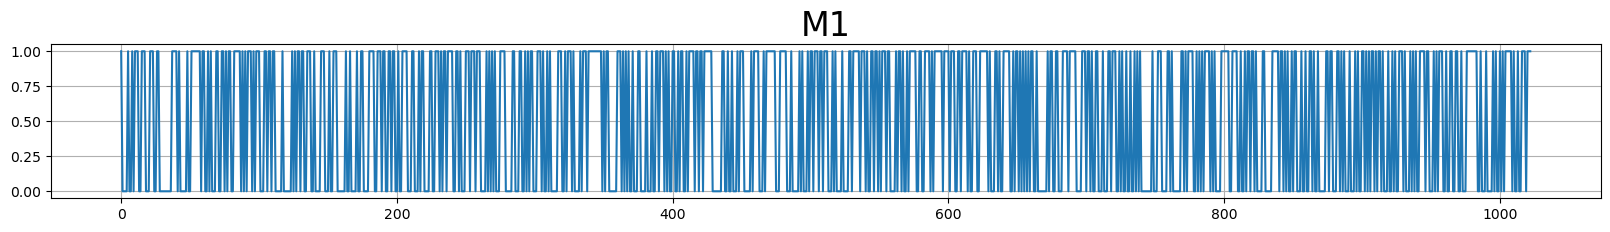

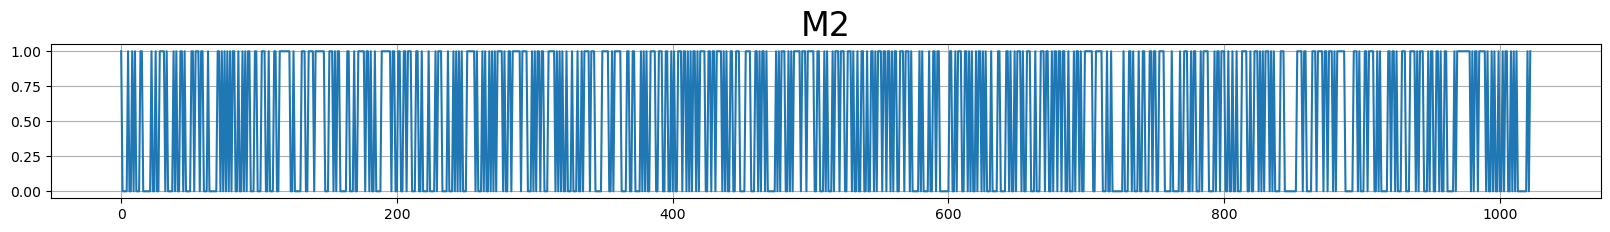

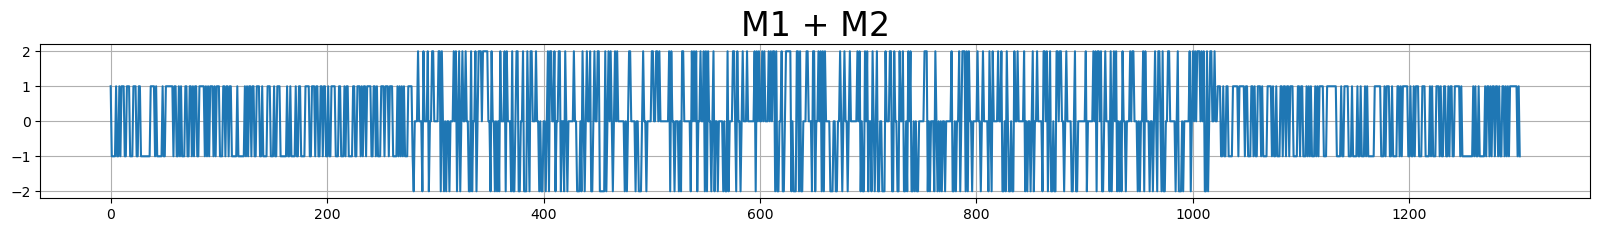

In [10]:
M1_pm = M1*2 - 1
M2_pm = M2*2 - 1
M_sum =  np.concatenate((M1_pm, np.zeros(280))) + np.concatenate((np.zeros(280), -M2_pm))
plt.figure(figsize=(20, 2))
plt.plot(M1)
plt.title("M1", fontsize=24)
plt.grid(True)
plt.figure(figsize=(20, 2))
plt.plot(M2)
plt.title("M2", fontsize=24)
plt.grid(True)
plt.figure(figsize=(20, 2))
plt.plot(M_sum)
plt.title("M1 + M2", fontsize=24)
plt.grid(True)

№2.3

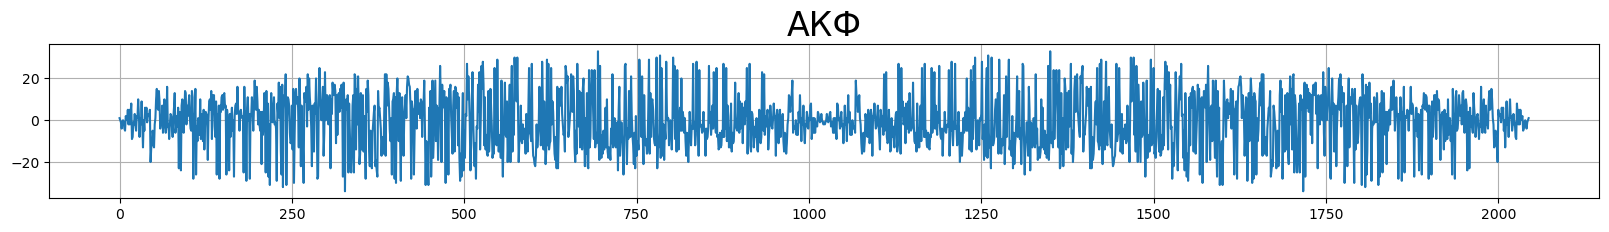

In [11]:
AKF = np.correlate(M1_pm, M1_pm, mode="full")
plt.figure(figsize=(20, 2))
plt.plot(AKF)
plt.title("АКФ", fontsize=24)
plt.grid(True)

№2.4

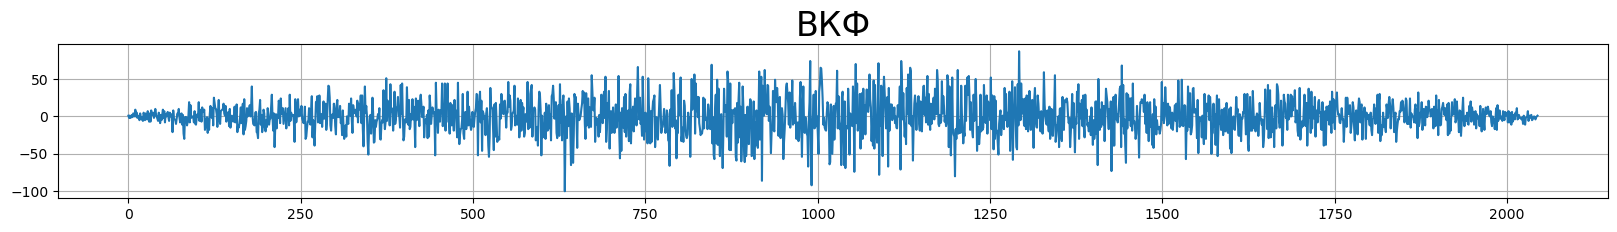

In [12]:
VKF = np.correlate(M1_pm, M2_pm, mode="full")
plt.figure(figsize=(20, 2))
plt.plot(VKF)
plt.title("ВКФ", fontsize=24)
plt.grid(True)

№2.5

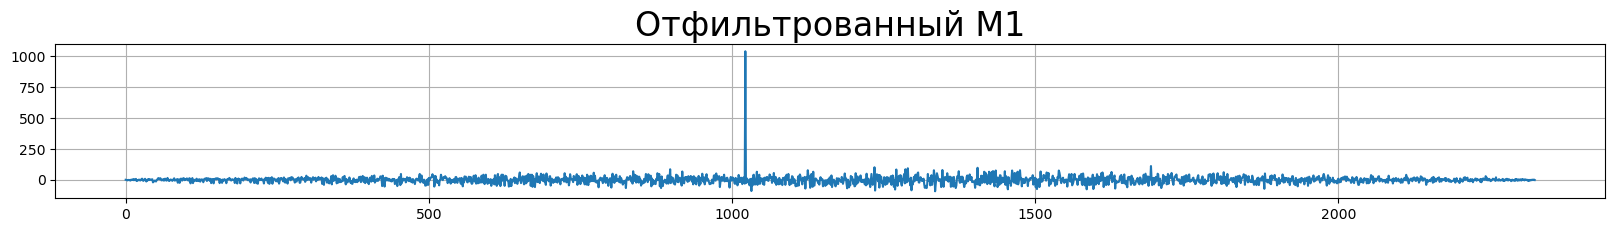

In [13]:
M1_f = np.correlate(M_sum, M1_pm, mode="full")
plt.figure(figsize=(20, 2))
plt.plot(M1_f)
plt.title("Отфильтрованный M1", fontsize=24)
plt.grid(True)

№2.6

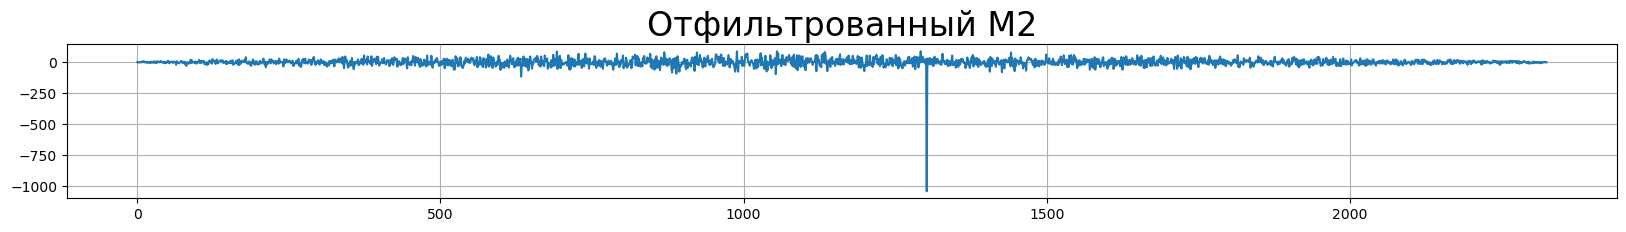

In [14]:
M2_f = np.correlate(M_sum, M2_pm, mode="full")
plt.figure(figsize=(20, 2))
plt.plot(M2_f)
plt.title("Отфильтрованный M2", fontsize=24)
plt.grid(True)

№2.7

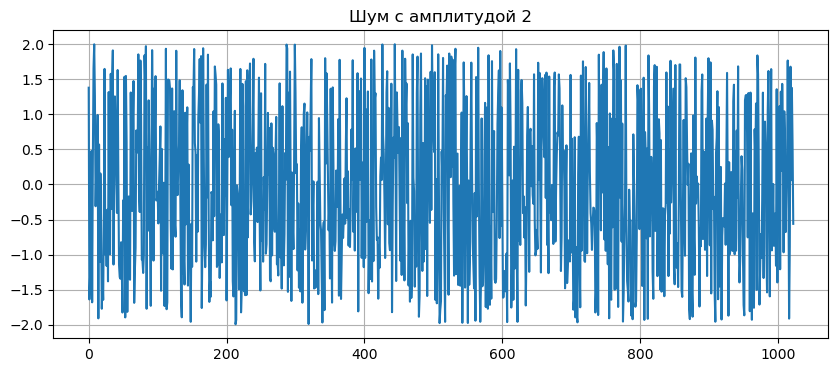

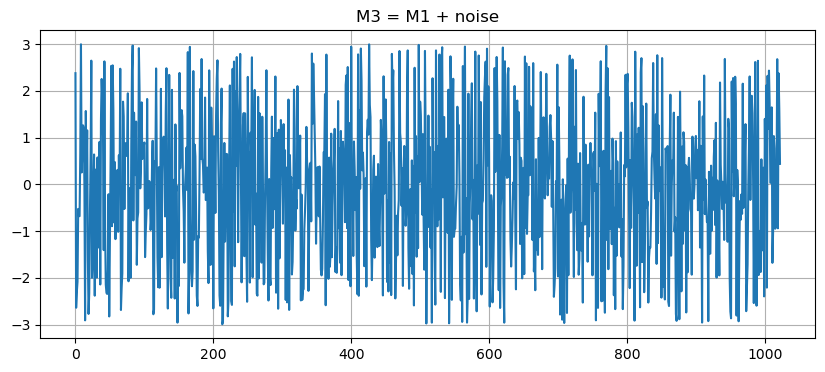

In [15]:
A_noise = 2
noise = np.random.default_rng().uniform(-A_noise, A_noise, len(M1_pm))
M3 = M1_pm + noise
plt.figure(figsize=(10, 4))
plt.plot(noise)
plt.title("Шум с амплитудой 2")
plt.grid(True)
plt.figure(figsize=(10, 4))
plt.plot(M3)
plt.title("M3 = M1 + noise")
plt.grid(True)

№2.8

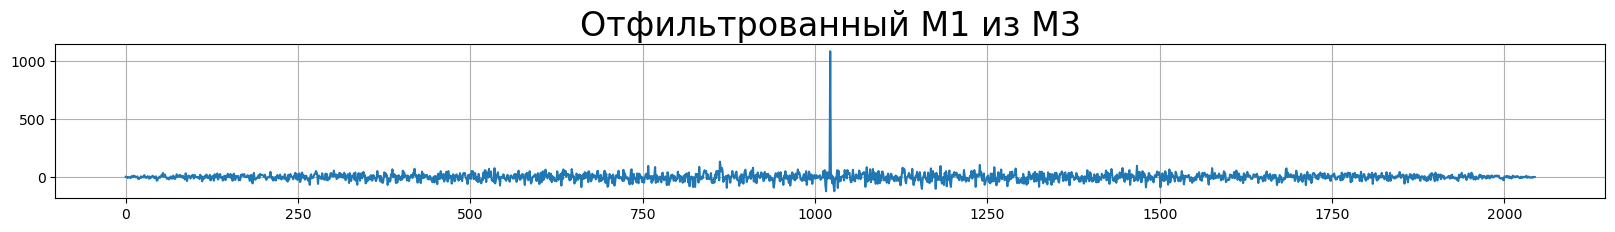

In [16]:
M1_from_M3 = np.correlate(M3, M1_pm, mode="full")
plt.figure(figsize=(20, 2))
plt.plot(M1_from_M3)
plt.title("Отфильтрованный M1 из M3", fontsize=24)
plt.grid(True)

№2.9

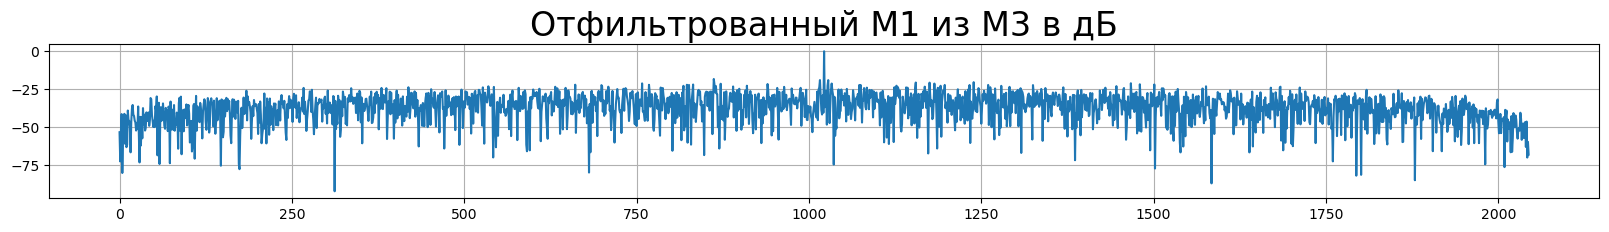

In [17]:
plt.figure(figsize=(20, 2))
plt.plot(20 * np.log10(np.abs(M1_from_M3 / max(abs(M1_from_M3)))))
plt.title("Отфильтрованный M1 из M3 в дБ", fontsize=24)
plt.grid(True)

№2.10

8.099999999999987 1.9380144666788746


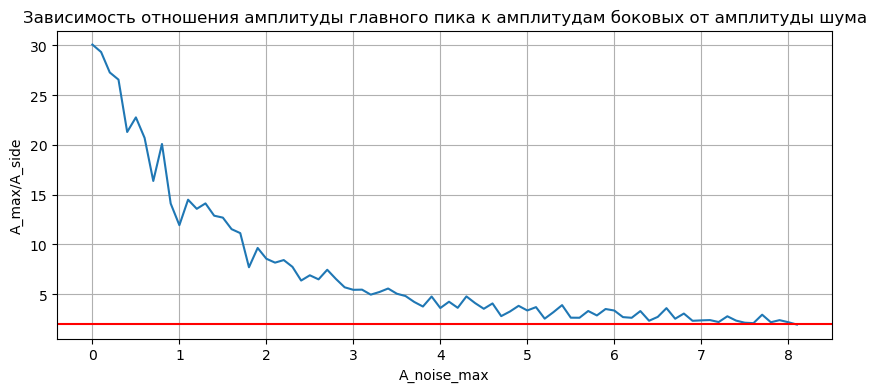

In [18]:
rng = np.random.default_rng(seed=6)
def otnoshenie_amplitud(M_pm, A_noise):
    noise = rng.uniform(-A_noise, A_noise, len(M_pm))
    M_noisy = M_pm + noise
    M_filter = np.correlate(M_noisy, M_pm, mode="full")
    
    A_max_index_M = np.argmax(abs(M_filter))
    M_filter_without_max = M_filter.copy()
    M_filter_without_max[A_max_index_M-5:A_max_index_M+5] = 0
    A_side_M = max(abs(M_filter_without_max))
    k = max(abs(M_filter)) / A_side_M
    return k

k_lin = []
A_noise_max = 0
k = otnoshenie_amplitud(M1_pm, A_noise_max)
k_lin.append(k)
while k > 2:
    A_noise_max += 0.1
    k = otnoshenie_amplitud(M1_pm, A_noise_max)
    k_lin.append(k)
print(A_noise_max, k)

A_lin = np.arange(0, A_noise_max + 0.1, 0.1)
plt.figure(figsize=(10, 4))
plt.plot(A_lin, k_lin)
plt.axhline(y = 2, color="r")
plt.title("Зависимость отношения амплитуды главного пика к амплитудам боковых от амплитуды шума")
plt.xlabel("A_noise_max")
plt.ylabel("A_max/A_side")
plt.grid(True)

№3.1

[ 1 -1  1 ...  1 -1  1]
[ 1 -1  1 ...  1 -1  1]


Text(0.5, 1.0, 'W2')

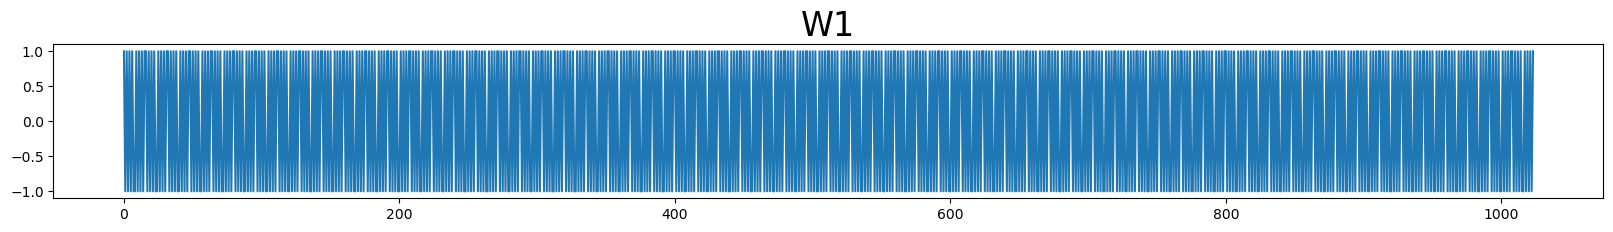

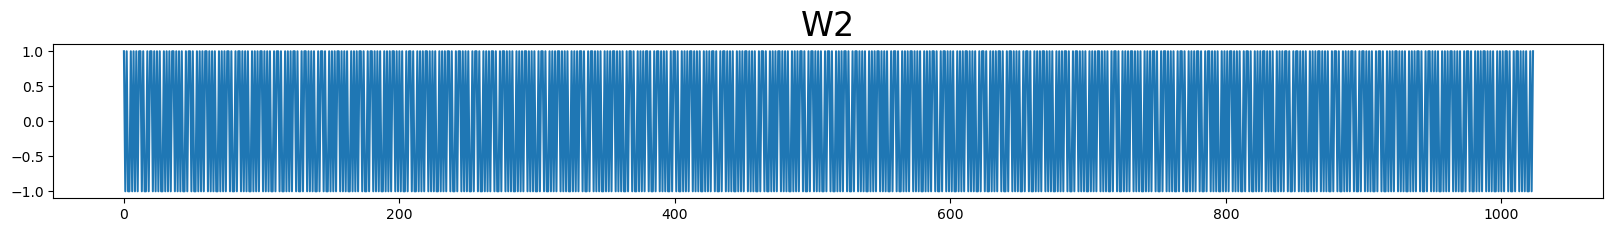

In [19]:
r = 10
data1 = 18
data2 = 378
W1 = sc.linalg.hadamard(2**r)[int(bin(data1)[:1:-1], 2)] # reverse data1
W2 = sc.linalg.hadamard(2**r)[int(bin(data2)[:1:-1], 2)] # reverse data2
print(W1)
print(W2)

plt.figure(figsize=(20, 2))
plt.plot(W1)
plt.title("W1", fontsize=24)
plt.figure(figsize=(20, 2))
plt.plot(W2)
plt.title("W2", fontsize=24)

№3.2

[ 2 -2  2 ...  2 -2  2]


Text(0.5, 1.0, 'W_sum = W1 + W2')

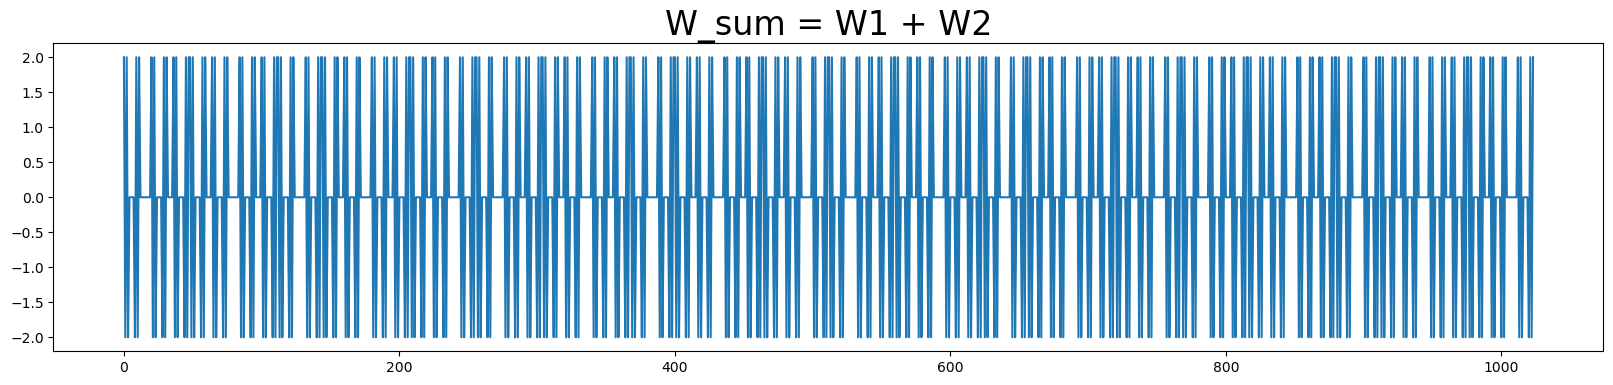

In [20]:
W_sum = W1 + W2
print(W_sum)
plt.figure(figsize=(20, 4))
plt.plot(W_sum)
plt.title("W_sum = W1 + W2", fontsize=24)

№3.3

Text(0.5, 1.0, 'Фильтрация W1 и W2 из W_sum')

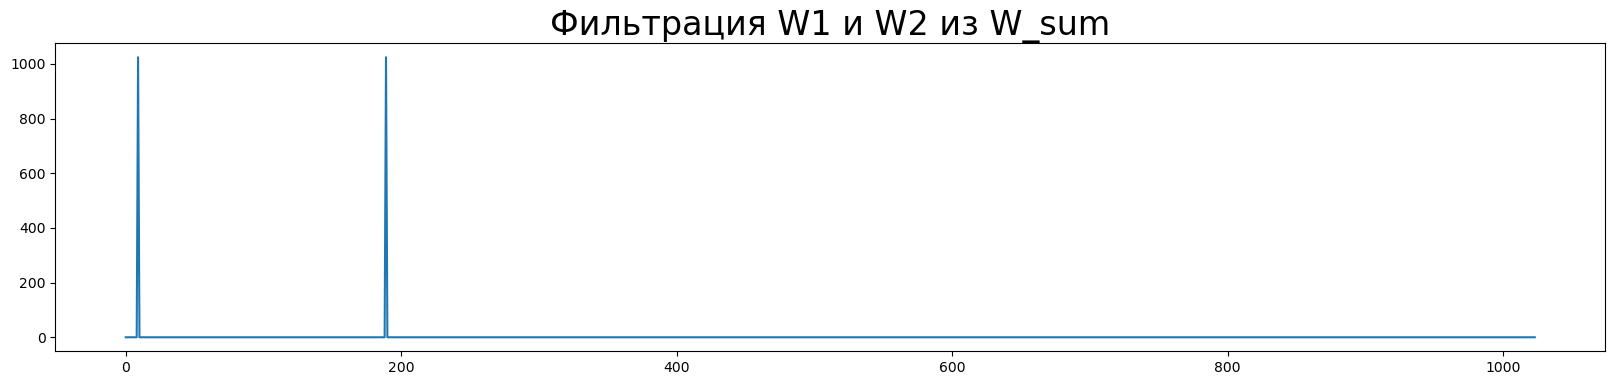

In [21]:
BPUA_W_sum = sp.discrete.transforms.fwht(W_sum)
plt.figure(figsize=(20, 4))
plt.plot(BPUA_W_sum)
plt.title("Фильтрация W1 и W2 из W_sum", fontsize=24)

№3.4

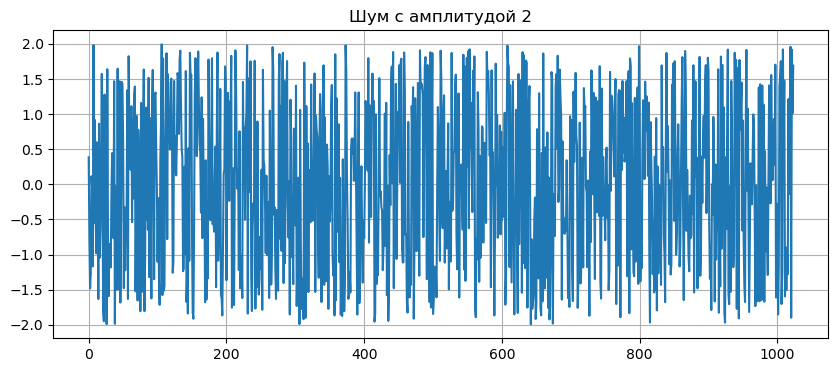

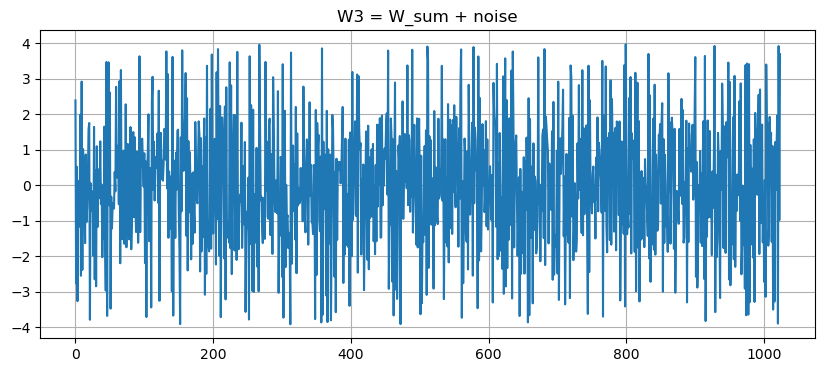

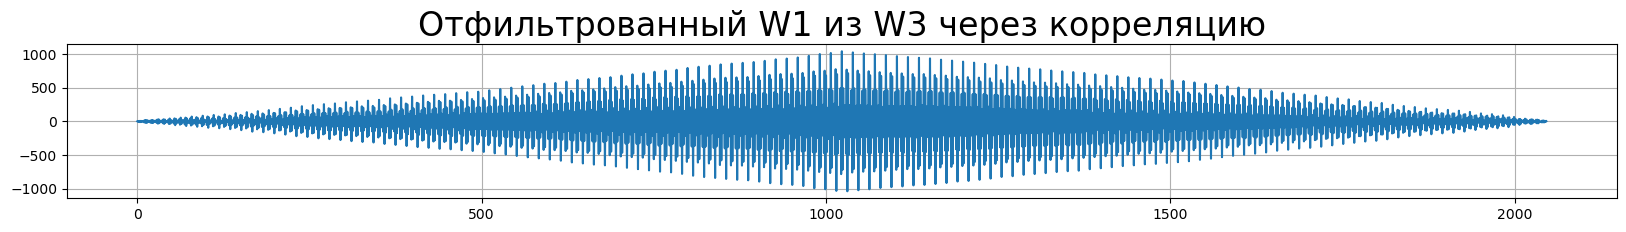

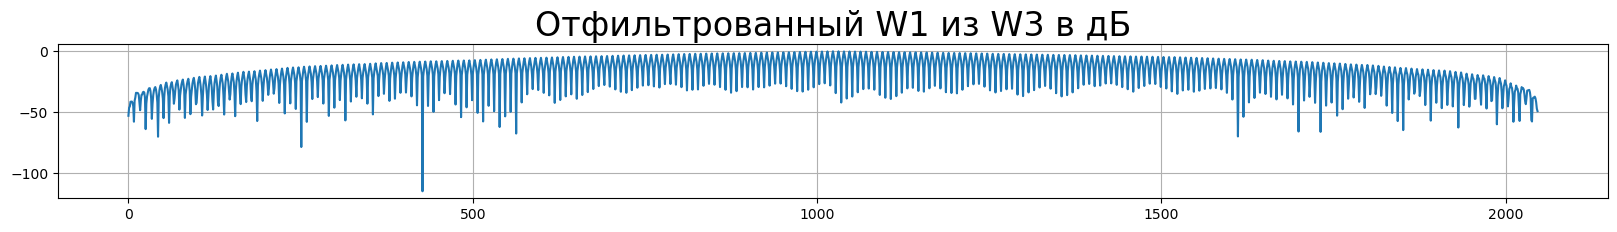

In [22]:
A_noise = 2
noise_W = np.random.default_rng().uniform(-A_noise, A_noise, len(W_sum))
W3 = W_sum + noise_W
plt.figure(figsize=(10, 4))
plt.plot(noise_W)
plt.title("Шум с амплитудой 2")
plt.grid(True)
plt.figure(figsize=(10, 4))
plt.plot(W3)
plt.title("W3 = W_sum + noise")
plt.grid(True)

# Фильтрация W1
W1_from_W3 = np.correlate(W3, W1, mode="full")
plt.figure(figsize=(20, 2))
plt.plot(W1_from_W3)
plt.title("Отфильтрованный W1 из W3 через корреляцию", fontsize=24)
plt.grid(True)

plt.figure(figsize=(20, 2))
plt.plot(20 * np.log10(np.abs(W1_from_W3 / max(abs(W1_from_W3)))))
plt.title("Отфильтрованный W1 из W3 в дБ", fontsize=24)
plt.grid(True)

№3.5

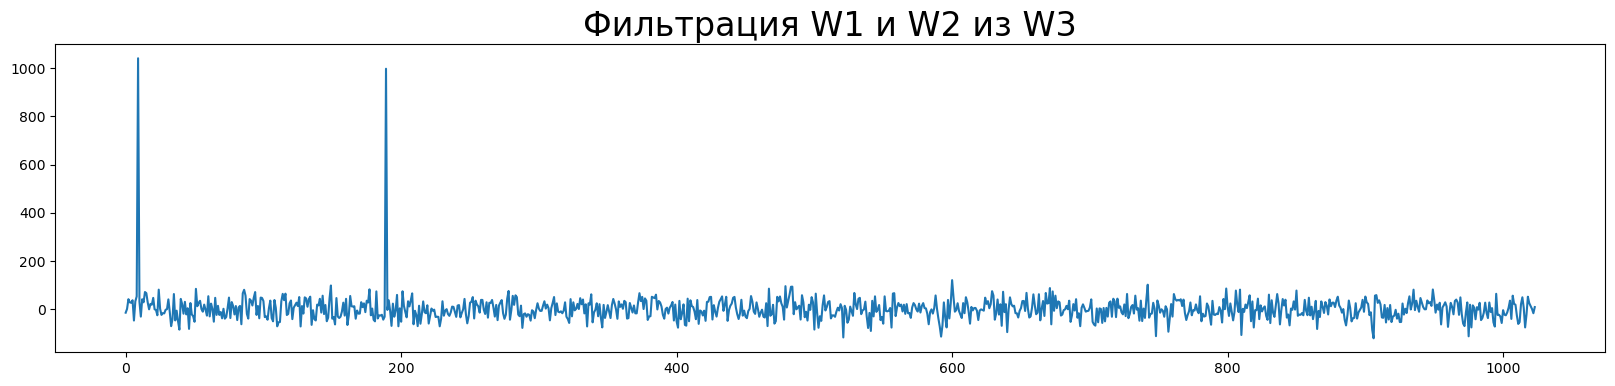

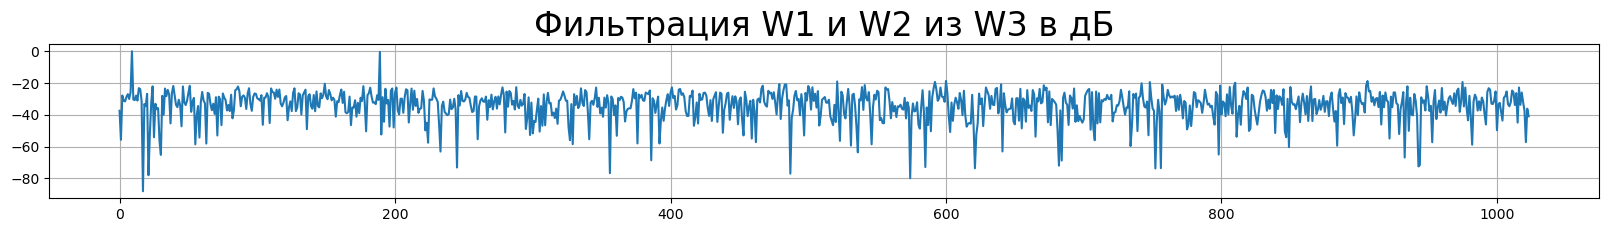

In [23]:
BPUA_W3 = np.array(sp.discrete.transforms.fwht(W3)).astype(float)
plt.figure(figsize=(20, 4))
plt.plot(BPUA_W3)
plt.title("Фильтрация W1 и W2 из W3", fontsize=24)
plt.figure(figsize=(20, 2))
plt.plot(20 * np.log10(np.abs(BPUA_W3 / max(np.abs(BPUA_W3)))))
plt.title("Фильтрация W1 и W2 из W3 в дБ", fontsize=24)
plt.grid(True)

№3.6

7.799999999999988 1.958553607958332


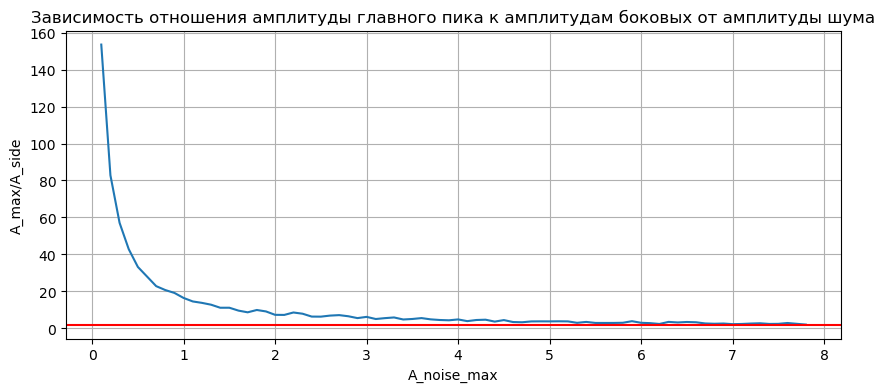

In [24]:
rng = np.random.default_rng(seed=6)
def otnoshenie_amplitud_walsh(W, A_noise):
    noise = rng.uniform(-A_noise, A_noise, len(W))
    W_noisy = W + noise
    W_filter = np.array(sp.discrete.transforms.fwht(W_noisy)).astype(float)

    A_max_W = max(abs(W_filter))
    A_max_index1 = np.argmax(abs(W_filter))
    W_filter[A_max_index1] = 0
    A_max_index2 = np.argmax(abs(W_filter))
    W_filter[A_max_index2] = 0
    A_side_W = max(abs(W_filter))
    k = A_max_W / A_side_W
    return k

k_lin = []
A_noise_max = 0
k = otnoshenie_amplitud_walsh(W_sum, A_noise_max)
k_lin.append(k)
while k > 2:
    A_noise_max += 0.1
    k = otnoshenie_amplitud_walsh(W_sum, A_noise_max)
    k_lin.append(k)
print(A_noise_max, k)

A_lin = np.arange(0, A_noise_max + 0.1, 0.1)
plt.figure(figsize=(10, 4))
plt.plot(A_lin, k_lin)
plt.axhline(y = 2, color="r")
plt.title("Зависимость отношения амплитуды главного пика к амплитудам боковых от амплитуды шума")
plt.xlabel("A_noise_max")
plt.ylabel("A_max/A_side")
plt.grid(True)

Дополнительные задания

№1

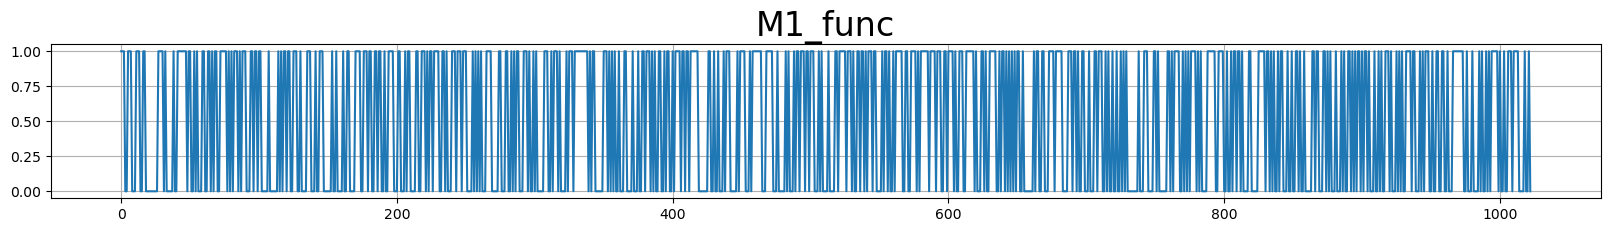

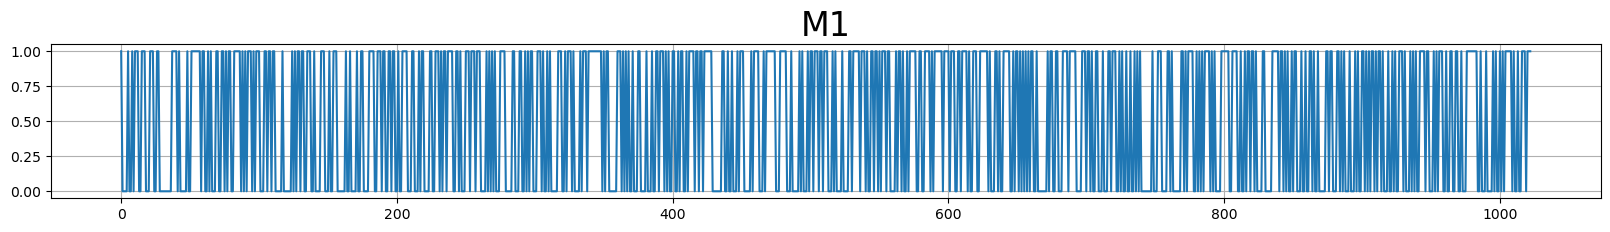

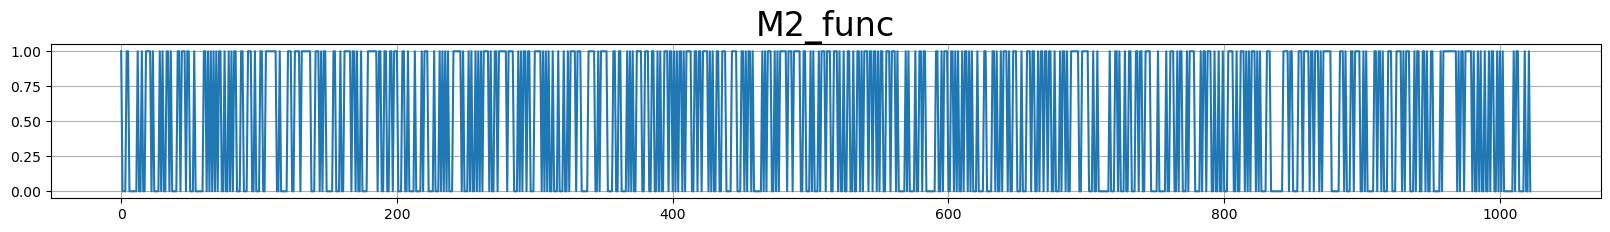

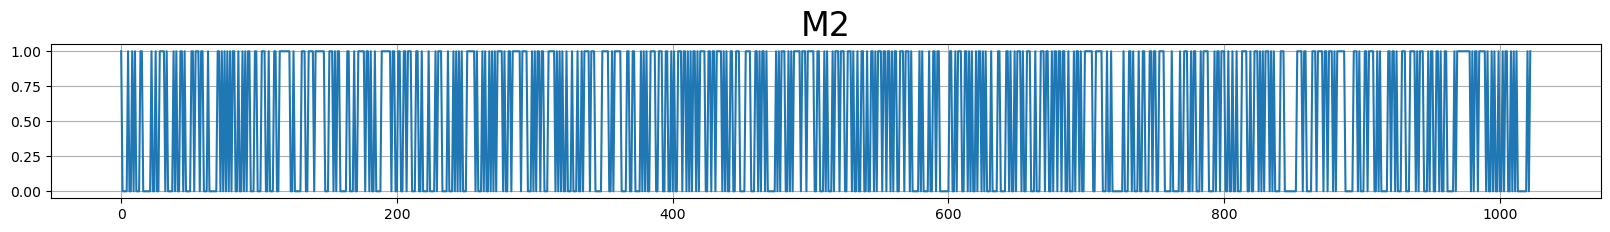

In [25]:
def M_seq(length, state, taps):
    phase = np.array(state)
    result = []
    for i in range(2**length - 1):
        s = phase[-1]
        for j in taps:
            s = s ^ phase[j - 1]
        result.append(phase[-1])
        phase = np.concatenate(([s], phase[0:-1]))
    return np.array(result)
M1_func = M_seq(10, state=np.array([1,0,0,0,0,1,0,0,1,0]), taps=[9,6,3,2,1])
M2_func = M_seq(10, state=np.array([1,0,0,0,0,1,0,0,1,0]), taps=[9,6,4,3,1])
plt.figure(figsize=(20, 2))
plt.plot(M1_func[::-1]) # Если перевернуть то совпадет, но по фазе сдвинуто на 10
plt.title("M1_func", fontsize=24)
plt.grid(True)
plt.figure(figsize=(20, 2))
plt.plot(M1)
plt.title("M1", fontsize=24)
plt.grid(True)
plt.figure(figsize=(20, 2))
plt.plot(M2_func[::-1])  # Если перевернуть и сдвинуть циклически вправо на 10, то совпадет
plt.title("M2_func", fontsize=24)
plt.grid(True)
plt.figure(figsize=(20, 2))
plt.plot(M2)
plt.title("M2", fontsize=24)
plt.grid(True)

№2

<ipython-input-44-70cc8a0d1944>:8: RuntimeWarning: overflow encountered in scalar add
  result[i] += signal[i - len(ref) + j] * ref[j]


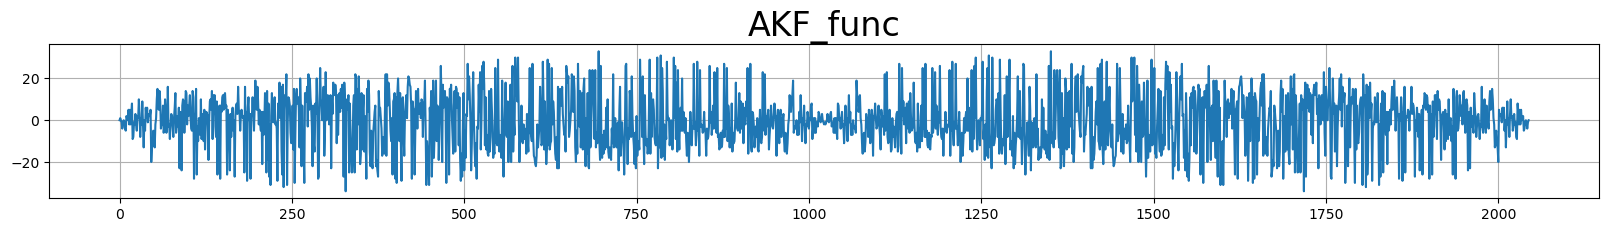

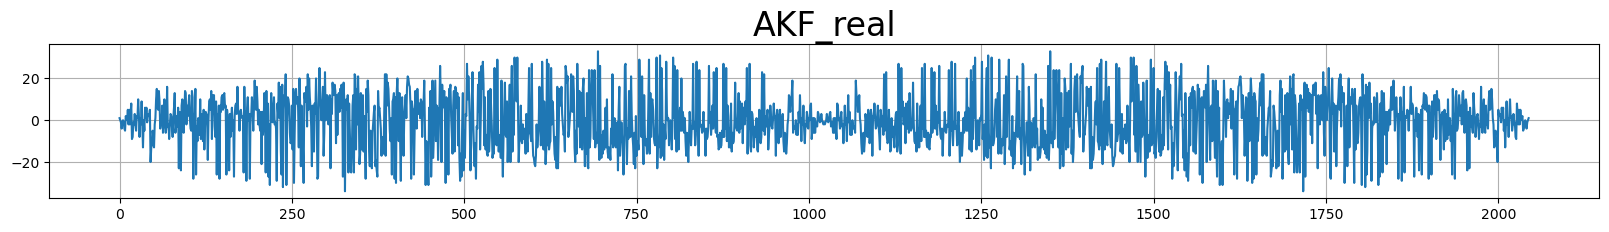

In [44]:
def sogl_filter(signal, ref):
    s = 0
    result_len = (len(signal) + len(ref) - 1)
    result = [0] * result_len
    for i in range(result_len):
        for j in range(len(ref)):
            if ((i - len(ref) + j) >= 0) and ((i - len(ref) + j) < len(signal)):
                result[i] += signal[i - len(ref) + j] * ref[j]
            else:
                result[i] += 0
    return result
    
AKF_func = sogl_filter(M1_pm, M1_pm)
plt.figure(figsize=(20, 2))
plt.plot(AKF_func)
plt.title("AKF_func", fontsize=24)
plt.grid(True)

plt.figure(figsize=(20, 2))
plt.plot(AKF)
plt.title("AKF_real", fontsize=24)
plt.grid(True)

№3

In [80]:
def automat_Walsh(r, C):
    result = [0] * (2**r)
    reg = np.array([0] * (2**r - 1))
    k = 2
    for i in range(0, r):
        for j in range(0, 2**i):
            if (i != 0) and (j != 0):
                result[k] = reg[2**i - 1] ^ C[i]
                reg = np.concatenate(([reg[2**i - 1] ^ C[i]], reg[1:]))
                k += 1
    return -(np.array(result)*2 - 1)
W1_func = automat_Walsh(10, np.concatenate((np.zeros(np.array(list(bin(data1)[:1:-1])).astype(int))))
print(W1_func)
W1

<class 'IndexError'>: index 5 is out of bounds for axis 0 with size 5

In [78]:
automat_Walsh(3, [0,1,1])

array([ 1,  1, -1, -1, -1, -1,  1,  1])